In [2]:
import scMPRAforge as scm
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster

In [3]:
local=True
if local:
    cluster=LocalCluster(memory_limit='48G')
    client = Client(cluster)
else:
    cluster=SLURMCluster(
        cores=5,#cores per slurm job
        memory="64G",#memory per slurm job
        processes=1,#dask workers per slurm job
        job_extra_directives=["-p day", 
            f"--job-name=simclust_worker",
            f"--time=0:20:00",
            f"--output=worker_%j.out"]
    )
    cluster.scale(jobs=2)
    client = Client(cluster,
            timeout=f"{10*60}s",   # Client <-> scheduler timeout 
            heartbeat_interval="20s",  # Worker heartbeat interval,
        )

2025-11-10 18:42:23,005 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 48G due to system memory limit of 24.00 GiB
2025-11-10 18:42:23,006 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 48G due to system memory limit of 24.00 GiB
2025-11-10 18:42:23,007 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 48G due to system memory limit of 24.00 GiB
2025-11-10 18:42:23,008 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 48G due to system memory limit of 24.00 GiB
2025-11-10 18:42:23,009 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 48G due to system memory limit of 24.00 GiB
2025-11-10 18:42:23,010 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 48G due to system memory limit of 24.00 GiB
2025-11-10 18:42:23,011 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 48G due to system memory limit of 24.00 GiB


In [4]:
from pathlib import Path

In [5]:
DATA_ROOT=Path("/gpfs/gibbs/pi/reilly/tabula_data")

In [6]:
mini=scm.scMPRA_data.from_tsv(DATA_ROOT/"simulated/fake_cres_v3.tsv")

In [7]:
mini.set_negative_controls(["nobody","weak"])
mini.set_reference_cell("blood")
mini.ortho_filter()

primordial=scm.ortho()
primordial.criss_cross(client=client,
                       dat=mini)

scMPRAforge: INFO: Dropped 0 of 24 (cell_type, cre_id) combos with fewer than 3 nonzero entries.


In [8]:
primordial.extract_params(client)

Metal device set to: Apple M4 ProMetal device set to: 

systemMemory: 24.00 GB
maxCacheSize: 8.88 GB

Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.88 GB

Metal device set to: Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.88 GB

Metal device set to: Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.88 GB

Metal device set to: Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.88 GB

Metal device set to: Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.88 GB

Metal device set to: Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.88 GB



In [11]:
primordial.compute_model_qc()

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns

In [15]:
def minimax(QC):
    x=[]
    for level in QC.keys():
        if QC[level]["success"]:
            x.append(QC[level]["dat"])
    x=pd.concat(x)
    print(f"min {min(x['mu'])}, max {max(x['mu'])}")

print("cre")
minimax(primordial.by_cre_qc)
print("ct")
minimax(primordial.by_cell_qc)

cre
min 1.978126147201754, max 221.61895577812152
ct
min 2.010672456499058, max 221.65955234824565


---
---
[0.9999562608074648, 0.9999785097691192, 0.9998687574339797, 0.9999964470110835, 0.9847462254289158, 0.9958087734142137, 0.9901915334002581, 0.9999889621337366, 0.999943902065301, 0.9999946470226253, 0.9999528955310198]


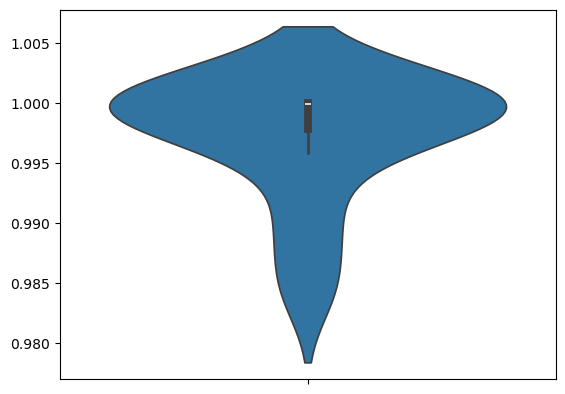

In [20]:
r=[]
for QC in [primordial.by_cre_qc,primordial.by_cell_qc]:
    print("---")
    
    for level in QC.keys():
        if QC[level]["success"]:
            if np.isnan(QC[level]["r_value"]):
                print(f"nan in {level}")
            else:
                if QC[level]["r_value"]<0.8:
                    print(f"low r {level}")
                r.append(QC[level]["r_value"])


sns.violinplot(r)

print(r)
#print(np.mean(r))
#for cell_type in QC:
#    print(f"{cell_type} : r={QC[cell_type]['r_value']}, slope={QC[cell_type]['slope']}")